In [65]:
import pandas as pd
import numpy as np
import re
import os
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import pandas as pd
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')


In [66]:
full_data = pd.read_csv("data_panel/full_panel_master.csv")
print(full_data)

    geo nace_r2  real_wage  year  ai_adoption  spec_ict  training_ict  \
0    AT       C      26.74  2021        9.610     28.56         22.98   
1    AT       C      26.18  2022       10.960     28.37         25.60   
2    AT       C      26.07  2023       12.310     29.20         25.83   
3    AT       C      27.05  2024       22.710     30.02         26.06   
4    AT       F      22.43  2021        3.120      8.64          8.28   
..   ..     ...        ...   ...          ...       ...           ...   
531  SK       G       8.45  2024       11.650     15.19         19.87   
532  SK       J      15.69  2021       18.190     70.76         55.96   
533  SK       J      14.79  2022       19.905     71.88         53.54   
534  SK       J      14.48  2023       21.620     70.80         58.16   
535  SK       J      14.67  2024       29.190     69.72         62.79   

     productivity    FSI  share_high_skill  tert_edu    hicp  log_prod  \
0          102.25  55.82             36.58      3

In [67]:
full_data = full_data.rename(columns={'log_wage' : 'log_wage_ij', 
                                      'tert_edu' : 'educ_ij',
                                      'log_hicp' : 'log_hicp_i', 
                                      'log_prod' : 'log_prdct_ij', 
                                      'share_high_skill' : 'h_skill_ij', 
                                      'unempl_r' : 'unempl_r_i', 
                                      'infl_r' : 'infl_r_i', 
                                      'log_gdp' : 'log_gdp_i', 
                                      'FSI' : 'fsi_ij',
                                      'ai_adoption' : 'ai_ij',
                                      'spec_ict' : 'ict_spec_ij', 
                                      'training_ict' : 'ict_tr_ij'})

print(full_data)

    geo nace_r2  real_wage  year   ai_ij  ict_spec_ij  ict_tr_ij  \
0    AT       C      26.74  2021   9.610        28.56      22.98   
1    AT       C      26.18  2022  10.960        28.37      25.60   
2    AT       C      26.07  2023  12.310        29.20      25.83   
3    AT       C      27.05  2024  22.710        30.02      26.06   
4    AT       F      22.43  2021   3.120         8.64       8.28   
..   ..     ...        ...   ...     ...          ...        ...   
531  SK       G       8.45  2024  11.650        15.19      19.87   
532  SK       J      15.69  2021  18.190        70.76      55.96   
533  SK       J      14.79  2022  19.905        71.88      53.54   
534  SK       J      14.48  2023  21.620        70.80      58.16   
535  SK       J      14.67  2024  29.190        69.72      62.79   

     productivity  fsi_ij  h_skill_ij  educ_ij    hicp  log_prdct_ij  \
0          102.25   55.82       36.58     31.8  111.46          4.63   
1          108.40   56.10       37.32  

In [68]:
duplicates = full_data[full_data.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [geo, nace_r2, real_wage, year, ai_ij, ict_spec_ij, ict_tr_ij, productivity, fsi_ij, h_skill_ij, educ_ij, hicp, log_prdct_ij, log_wage_ij, log_hicp_i, unempl_r_i, infl_r_i, gdp, log_gdp_i]
Index: []


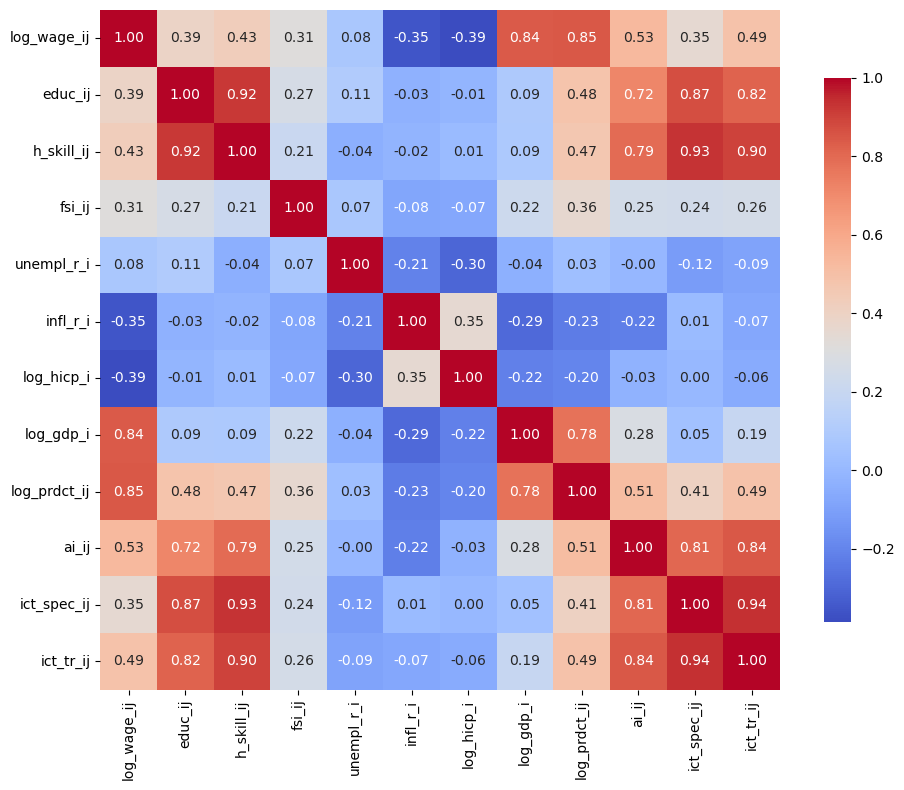

In [69]:
# Choose variables for the matrix
cols = [
    "log_wage_ij", "educ_ij", "h_skill_ij", "fsi_ij", "unempl_r_i", "infl_r_i", 
    "log_hicp_i", "log_gdp_i", "log_prdct_ij", "ai_ij", "ict_spec_ij", "ict_tr_ij"
]

corr = full_data[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.tight_layout()
plt.show()


In [70]:
print(corr)

              log_wage_ij   educ_ij  h_skill_ij    fsi_ij  unempl_r_i  \
log_wage_ij      1.000000  0.391919    0.429491  0.313104    0.077938   
educ_ij          0.391919  1.000000    0.920435  0.268441    0.106239   
h_skill_ij       0.429491  0.920435    1.000000  0.207809   -0.040501   
fsi_ij           0.313104  0.268441    0.207809  1.000000    0.074365   
unempl_r_i       0.077938  0.106239   -0.040501  0.074365    1.000000   
infl_r_i        -0.353831 -0.030478   -0.018089 -0.082018   -0.211670   
log_hicp_i      -0.386154 -0.014578    0.011221 -0.073711   -0.302671   
log_gdp_i        0.838540  0.094917    0.090271  0.220581   -0.039134   
log_prdct_ij     0.846740  0.480259    0.468433  0.356481    0.031331   
ai_ij            0.532991  0.715673    0.794594  0.250067   -0.002673   
ict_spec_ij      0.350511  0.872463    0.933833  0.244436   -0.117507   
ict_tr_ij        0.486636  0.816345    0.898823  0.257359   -0.089570   

              infl_r_i  log_hicp_i  log_gdp_i  log

# UPDATED DATASET FOR THE 2021-2024

In [71]:
data_24 = full_data[full_data['year'] == 2024]
data_23 = full_data[full_data['year'] == 2023]
data_22 = full_data[full_data['year'] == 2022]
data_21 = full_data[full_data['year'] == 2021]

In [72]:
def models_diagnostic(model): 
    print(f"DIAGNOSTIC TESTS")

    # 1. Breusch-Pagan Test for Heteroskedasticity
    name = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
    test = sms.het_breuschpagan(model.resid, model.model.exog)
    print(f"\nBreusch-Pagan Test:\n{lzip(name, test)}")
    if test[1] < 0.05:
        print(">> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').")
    else:
        print(">> RESULT: Homoskedasticity (Variance is constant).")

    # 2. Ramsey RESET Test (Linearity)
    # power=2 means checking for squared terms
    reset_test = sms.linear_reset(model, power=2, test_type='fitted', use_f=True)
    print(f"\nRamsey RESET Test:\n{reset_test}")

    # # VISUAL CHECKS
    # fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # # Plot 1: Residuals vs Fitted (Check for patterns/heteroskedasticity visually)
    # ax[0].scatter(model.fittedvalues, model.resid)
    # ax[0].axhline(0, color='red', linestyle='--')
    # ax[0].set_xlabel("Fitted Values")
    # ax[0].set_ylabel("Residuals")
    # ax[0].set_title("Residuals vs Fitted")

    # # Plot 2: Q-Q Plot (Check Normality)
    # stats.probplot(model.resid, dist="norm", plot=ax[1])
    # ax[1].set_title("Q-Q Plot")

    # plt.show()

#### 2021

##### Baseline models

In [73]:
model_1 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i + C(geo) + C(nace_r2)",
    data=data_21
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     142.9
Date:                Sun, 31 May 2026   Prob (F-statistic):           7.56e-70
Time:                        00:27:36   Log-Likelihood:                 143.87
No. Observations:                 134   AIC:                            -215.7
Df Residuals:                      98   BIC:                            -111.4
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.4919      0.038    -

In [74]:
models_diagnostic(model_1)    

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 59.71005858353698), ('p-value', 0.013777804040877478), ('f-value', 2.2504818397508357), ('f p-value', 0.0009533215868131954)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=33.84907500561727, p=7.661498978323216e-08, df_denom=97, df_num=1>


In [75]:
model_2 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i",
    data=data_21
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     179.9
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.05e-62
Time:                        00:27:37   Log-Likelihood:                 39.728
No. Observations:                 134   AIC:                            -63.46
Df Residuals:                     126   BIC:                            -40.27
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.5685      0.466    -11.948   

In [76]:
models_diagnostic(model_2)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 46.8780889402053), ('p-value', 5.896116418985454e-08), ('f-value', 9.685343108974772), ('f p-value', 1.313002661199944e-09)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=14.336482313974145, p=0.00023621535379415138, df_denom=125, df_num=1>


In [77]:
model_3 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + C(geo) + C(nace_r2)",
    data=data_21
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     142.9
Date:                Sun, 31 May 2026   Prob (F-statistic):           7.56e-70
Time:                        00:27:37   Log-Likelihood:                 143.87
No. Observations:                 134   AIC:                            -215.7
Df Residuals:                      98   BIC:                            -111.4
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.0733      0.144     

In [78]:
models_diagnostic(model_3)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 59.71005858353835), ('p-value', 0.010419906748429936), ('f-value', 2.2504818397509285), ('f p-value', 0.0009533215868126768)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=33.84907500560399, p=7.661498978361927e-08, df_denom=97, df_num=1>


In [79]:
model_4 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i",
    data=data_21
).fit()

print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     86.75
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.64e-42
Time:                        00:27:37   Log-Likelihood:                -11.752
No. Observations:                 134   AIC:                             37.50
Df Residuals:                     127   BIC:                             57.79
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.2230      0.212     -1.051   

In [80]:
models_diagnostic(model_4)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 36.109024480396094), ('p-value', 2.625337555631053e-06), ('f-value', 7.807744082415322), ('f p-value', 3.657989498510418e-07)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=40.15973346683762, p=3.7967409301215315e-09, df_denom=126, df_num=1>


In [81]:
model_5 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + C(geo) + C(nace_r2)",
    data=data_21
).fit()

print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     142.9
Date:                Sun, 31 May 2026   Prob (F-statistic):           7.56e-70
Time:                        00:27:37   Log-Likelihood:                 143.87
No. Observations:                 134   AIC:                            -215.7
Df Residuals:                      98   BIC:                            -111.4
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5299      0.192     

In [82]:
models_diagnostic(model_5)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 59.71005858353525), ('p-value', 0.005729153601985556), ('f-value', 2.250481839750719), ('f p-value', 0.0009533215868138549)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=33.84907500561692, p=7.66149897832419e-08, df_denom=97, df_num=1>


In [83]:
model_6 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij",
    data=data_21
).fit()

print(model_6.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     117.5
Date:                Sun, 31 May 2026   Prob (F-statistic):           5.07e-42
Time:                        00:27:37   Log-Likelihood:                -18.025
No. Observations:                 134   AIC:                             46.05
Df Residuals:                     129   BIC:                             60.54
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.5587      0.157     -3.551   

In [84]:
models_diagnostic(model_6)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 24.964876733830163), ('p-value', 5.113453844072434e-05), ('f-value', 7.384017649988066), ('f p-value', 2.1841105175225604e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=36.9488968526825, p=1.2958008085515662e-08, df_denom=128, df_num=1>


In [85]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula

def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula


# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[model_1, model_2,model_3, model_4, model_5, model_6],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(1) Baseline', '(2) Baseline (no FE)', '(3) Baseline (GDP excl) ', '(4) Baseline (no FE, GDP excl)', '(5) No macro controls', '(6) No macro controls (no FE)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)
print(results_table)


                (1) Baseline (2) Baseline (no FE) (3) Baseline (GDP excl)  (4) Baseline (no FE, GDP excl) (5) No macro controls (6) No macro controls (no FE)
-------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept       -0.492***    -5.569***            2.073***                 -0.223                         2.530***              -0.559***                    
                (0.038)      (0.466)              (0.144)                  (0.212)                        (0.192)               (0.157)                      
C(geo)[T.BE]    0.105                             0.004                                                   0.004                                              
                (0.065)                           (0.066)                                                 (0.067)                                            
C(geo)[T.BG]    -0.814***                         -

1. The "Education vs. Skills" Puzzle (Measurement Matter)
Observation: In Model 2 and 4 (No Country FE), h_skill_ij (High Skill Occupation) is highly significant and positive ($0.012^{}$), while educ_ij (Tertiary Education) is significant but negative ($-0.007^{}$ or $-0.011^{***}$).

Conclusion: Occupational structure matters more than formal education degrees. Once the control for productivity and the specific job type (high-skill occupation), simply having a degree doesn't automatically raise wages—in fact, it might capture some over-education effects or sectoral composition issues. This supports focusing on active skill measures (like  ICT training variable later) rather than just static educational attainment.

2. The Dominance of Country Heterogeneity (R-squared Gap)
Observation:

Model 4 (No Country FE, GDP Excl): $R^2 = 0.804$

Model 3 (Country FE, GDP Excl): $R^2 = 0.981$

Conclusion: Country-specific factors explain ~18% of the variation that sector and productivity alone cannot. This confirms that any analysis without Country FE (or strong country controls like HICP/GDP) risks Omitted Variable Bias. The fact that $R^2$ jumps so high suggests that national wage setting institutions (unions, minimum wages, price levels) are massive drivers of the wage level.

3. The "Macro Instability" (be careful)
Observation: Look at the coefficient for log_prdct_ij (Productivity).

In Model 4 (No FE): It is 0.782* (Very high, close to 1:1).

In Model 3 (With FE): It drops to 0.075*.

Conclusion: Most of the "productivity-wage" link is actually a cross-country phenomenon, not a within-sector one. Rich countries have high productivity and high wages (Model 4). But within a specific country (Model 3), being a slightly more productive sector only yields a small wage premium ($0.075$).

Implication for the Hypothesis: If AI increases productivity, don't expect it to double wages overnight. The "within-country" transmission channel is stiff.

4. Firm Size is a Weak Predictor
Observation: fsi_ij is only marginally significant ($0.002^{*}$) in FE models and insignificant ($0.000$) in others.

Conclusion: Unlike productivity or skills, simply being in a sector with large firms doesn't guarantee higher wages once we control for the other factors. This allows ud to treat fsi as a minor control rather than a major driver.



MODELS TEST RESULTS: 
Heteroskedasticity is Universal (Breusch-Pagan Test)
In every single model (1 through 6), the Breusch-Pagan test returns a p-value $< 0.05$ (often $< 0.001$).

Our error terms do not have constant variance. This is expected in cross-country wage data (large countries like Germany have different variance than small ones like Malta).
We must use robust standard errors in all our final regressions.

In statsmodels, add .fit(cov_type='HC3') (or 'HC1').

Note: This will correct our t-statistics and p-values. It won't change the coefficients, but it makes our inference valid.

2. Functional Form Misspecification (Ramsey RESET Test)
Result: In every single model, the Ramsey RESET test is highly significant ($p < 0.001$).

Interpretation: The model is "misspecified" in its linear form. This means the relationship between our variables isn't a simple straight line ($y = ax + b$).This strongly supports our hypothesis that interaction terms (moderation) are needed. The RESET test detects if squared terms or interactions are missing.

Since the linear models fail this test, it statistically justifies adding the $AI \times ICT$ interaction terms we planned. You can explicitly say: "The Ramsey RESET test rejected the linear specification, motivating the inclusion of interaction terms to capture non-linear moderation effects."

3. Normality is "Acceptable" (Jarque-Bera)
Result:

Models 1, 3, 5 (With FE): Jarque-Bera p-value $\approx 0.15$ (Do not reject Normality). The residuals are normal.

Models 2, 4, 6 (No FE): Jarque-Bera p-value $< 0.05$ (Reject Normality).

The Fixed Effects models (1, 3, 5) fit the data distribution much better. The non-FE models leave behind some skewness (likely because they fail to account for the specific wage structures of different countries).

We need to rely more on the FE models (1, 3, 5) for inference, as their residuals satisfy the normality assumption better.

4. Multicollinearity Warning (Condition Number)
Result:

Models 1, 3, 5 (With FE): Condition Number is massive ($10^{16}$ or $10^{17}$).

Models 2, 4, 6 (No FE): Condition Number is moderate ($500 - 2000$).

Interpretation: The massive condition number in the FE models confirms the "perfect collinearity" we discussed (Country Dummies vs. Macro variables). Python handles this by effectively dropping the collinear macro variables behind the scenes (or making their SEs huge), but it's a signal that we should typically drop the explicit macro variables (Inflation, Unemployment) when using Country FE to clean up the math.

In [86]:
formulas = [
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij",
]

for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_21, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i + C(geo) + C(nace_r2)
--------------------------------------------------
        feature       VIF
   C(geo)[T.NO]       inf
   C(geo)[T.LT]       inf
       infl_r_i       inf
     unempl_r_i       inf
   C(geo)[T.SK]       inf
   C(geo)[T.SI]       inf
   C(geo)[T.SE]       inf
   C(geo)[T.RO]       inf
   C(geo)[T.PT]       inf
   C(geo)[T.PL]       inf
   C(geo)[T.BE]       inf
   C(geo)[T.NL]       inf
   C(geo)[T.MT]       inf
   C(geo)[T.LV]       inf
      log_gdp_i       inf
   C(geo)[T.IT]       inf
   C(geo)[T.EE]       inf
   C(geo)[T.BG]       inf
   C(geo)[T.IE]       inf
   C(geo)[T.CY]       inf
   C(geo)[T.DE]       inf
   C(geo)[T.DK]       inf
   C(geo)[T.CZ]       inf
   C(geo)[T.ES]       inf
   C(geo)[T.FI]       inf
   C(geo)[T.FR]       inf
   C(geo)[T.HR]       inf
   C(geo)[T.HU]       inf
     h_skill_ij 66.228675
        educ_ij 3

The "Perfect Collinearity" of Country FE and Macro Controls (Models 1 & 3). This confirms mathematically that we cannot include country-level macro variables and Country Fixed Effects in the same cross-sectional model.

The "Skill Cluster" Explosion (Models 1, 3, 5): 

- h_skill_ij: VIF ~ 66.2

- educ_ij: VIF ~ 37.2

- C(nace_r2)[T.J]: VIF ~ 27.2

This is dangerously high (Rule of thumb: VIF > 10 is problematic). It means the model cannot tell the difference between "High Skill Occupation," "Tertiary Education," and "The Tech Sector (J)." Sector J (Information/Communication) is almost purely defined by high-skill, high-education workers. By putting all three in, we are asking the model: "What is the effect of being in the Tech sector, holding education and skill constant?" But we can't hold them constant because they are defining features of the sector.
We could think about dropping educ_ij. h_skill_ij (Occupational skill) usually has a more direct link to wages. Or, drop both if we are including Sector FE and want to focus purely on AI/ICT as the "new" skill variable. We need to use precisely educ_ij and h_skill_variable.

Productivity-GDP: When we remove GDP (Model 4), the VIF for log_prdct_ij drops to 1.6. This is much cleaner. It suggests that without GDP, "Productivity" captures both the sector's efficiency and the country's development level. 

##### Include AI and ICT variables 

In [87]:
model_7 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)", 
    data=data_21
).fit(cov_type='HC3')

print(model_7.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     225.5
Date:                Sun, 31 May 2026   Prob (F-statistic):           5.69e-79
Time:                        00:27:37   Log-Likelihood:                 148.77
No. Observations:                 134   AIC:                            -223.5
Df Residuals:                      97   BIC:                            -116.3
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5822      0.274     

In [88]:
models_diagnostic(model_7)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 58.11656093060196), ('p-value', 0.01120883922446168), ('f-value', 2.063583920945766), ('f p-value', 0.002701988212348333)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=23.63567316434395, p=4.540089177217049e-06, df_denom=96, df_num=1>


In [89]:
model_8 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + ai_ij + unempl_r_i + infl_r_i + log_gdp_i",
    data=data_21
).fit(cov_type='HC3')

print(model_8.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     170.4
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.01e-63
Time:                        00:27:37   Log-Likelihood:                 42.754
No. Observations:                 134   AIC:                            -67.51
Df Residuals:                     125   BIC:                            -41.43
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.3592      0.505    -10.615   

In [90]:
models_diagnostic(model_8)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 49.769421598069044), ('p-value', 4.5256001715198683e-08), ('f-value', 9.232362251616705), ('f p-value', 6.207865121429332e-10)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=29.921032383273673, p=2.3790533405160374e-07, df_denom=124, df_num=1>


In [ ]:
model_9 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    data=data_21
).fit(cov_type='HC3')

print(model_9.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     249.7
Date:                Sun, 31 May 2026   Prob (F-statistic):           4.36e-81
Time:                        00:27:37   Log-Likelihood:                 150.20
No. Observations:                 134   AIC:                            -226.4
Df Residuals:                      97   BIC:                            -119.2
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5275      0.265     

In [92]:
models_diagnostic(model_9)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 58.253591158790464), ('p-value', 0.010866631748943954), ('f-value', 2.0721915067390886), ('f p-value', 0.0025690391547964152)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=22.270741578905906, p=8.049469595164558e-06, df_denom=96, df_num=1>


In [ ]:
model_10 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)", 
    data=data_21
).fit(cov_type='HC3')

print(model_10.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     207.5
Date:                Sun, 31 May 2026   Prob (F-statistic):           7.35e-77
Time:                        00:27:37   Log-Likelihood:                 155.45
No. Observations:                 134   AIC:                            -234.9
Df Residuals:                      96   BIC:                            -124.8
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [94]:
multiplier = 100
ai_spec_iter = 'I(ai_ij * ict_spec_ij)'

# Original coefficient and SE
orig_coef = model_10.params[ai_spec_iter]
orig_se = model_10.bse[ai_spec_iter]

# Scaled coefficient and SE
scaled_coef = orig_coef * multiplier
scaled_se = orig_se * multiplier

print(f"Original {ai_spec_iter}: {orig_coef:.6f} (SE: {orig_se:.6f})")
print(f"Table-ready {ai_spec_iter} (x{multiplier}): {scaled_coef:.3f} (SE: {scaled_se:.3f})")

Original I(ai_ij * ict_spec_ij): -0.000156 (SE: 0.000070)
Table-ready I(ai_ij * ict_spec_ij) (x100): -0.016 (SE: 0.007)


In [95]:
models_diagnostic(model_10)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 63.73886439484231), ('p-value', 0.004074958044405811), ('f-value', 2.353740963621941), ('f p-value', 0.0004520962135937513)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=19.144151471672753, p=3.108243155241648e-05, df_denom=95, df_num=1>


In [ ]:
model_11 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",  
    data=data_21
).fit(cov_type='HC3')

print(model_11.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     230.5
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.00e-79
Time:                        00:27:37   Log-Likelihood:                 148.21
No. Observations:                 134   AIC:                            -222.4
Df Residuals:                      97   BIC:                            -115.2
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4477      0.274     

In [97]:
models_diagnostic(model_11)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 57.04387711424349), ('p-value', 0.014248951141459725), ('f-value', 1.9972622322491371), ('f p-value', 0.003978487397680133)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=28.302332335983767, p=6.777724187954688e-07, df_denom=96, df_num=1>


In [98]:
model_12 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)", # h_skill_ij +
    data=data_21
).fit(cov_type='HC3')

print(model_12.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     218.8
Date:                Sun, 31 May 2026   Prob (F-statistic):           5.91e-78
Time:                        00:27:37   Log-Likelihood:                 157.04
No. Observations:                 134   AIC:                            -238.1
Df Residuals:                      96   BIC:                            -128.0
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.5965 

In [99]:
ai_tr_iter = 'I(ai_ij * ict_tr_ij)'
# Original coefficient and SE
orig_coef = model_12.params[ai_tr_iter]
orig_se = model_12.bse[ai_tr_iter]
# Scaled coefficient and SE
scaled_coef = orig_coef * multiplier
scaled_se = orig_se * multiplier
print(f"Original {ai_tr_iter}: {orig_coef:.6f} (SE: {orig_se:.6f})")
print(f"Table-ready {ai_tr_iter} (x{multiplier}): {scaled_coef:.3f} (SE: {scaled_se:.3f})")

Original I(ai_ij * ict_tr_ij): -0.000250 (SE: 0.000082)
Table-ready I(ai_ij * ict_tr_ij) (x100): -0.025 (SE: 0.008)


In [100]:
models_diagnostic(model_12)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 64.59167928870427), ('p-value', 0.003314328679003512), ('f-value', 2.414540795985368), ('f p-value', 0.00031295834430696776)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=21.655707897840387, p=1.0558569774882523e-05, df_denom=95, df_num=1>


In [ ]:
def has_country_fe(m):

    return 'C(geo)' in m.model.formula

def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula


# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[model_7, model_8, model_9, model_10, model_11, model_12], 
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(7)', '(8)', '(9)', '(10)', '(11)', '(12)'], 
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)


print(results_table)


                          (7)       (8)       (9)       (10)      (11)      (12)  
----------------------------------------------------------------------------------
Intercept              2.582***  -5.359*** 2.528***  2.604***  2.448***  2.597*** 
                       (0.274)   (0.505)   (0.265)   (0.251)   (0.274)   (0.243)  
C(nace_r2)[T.F]        0.039               0.067     0.071     0.060     0.050    
                       (0.078)             (0.083)   (0.082)   (0.078)   (0.073)  
C(nace_r2)[T.G]        -0.038              -0.036    -0.042    -0.038    -0.053   
                       (0.037)             (0.036)   (0.034)   (0.038)   (0.034)  
C(nace_r2)[T.H]        -0.054              -0.042    -0.036    -0.007    -0.015   
                       (0.052)             (0.039)   (0.039)   (0.048)   (0.045)  
C(nace_r2)[T.I]        -0.197**            -0.167*   -0.167**  -0.160*   -0.173** 
                       (0.087)             (0.089)   (0.083)   (0.091)   (0.080)  
C(n

In [102]:
formulas = [
"log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)", 
"log_wage_ij ~  educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + ai_ij + unempl_r_i + infl_r_i + log_gdp_i",

"log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij  + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]

for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_21, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 535.443658
     h_skill_ij  66.229674
        educ_ij  37.302126
C(nace_r2)[T.J]  30.487144
   log_prdct_ij  10.819290
          ai_ij   8.610570
C(nace_r2)[T.F]   6.897732
         fsi_ij   6.773421
   C(geo)[T.ES]   3.884771
   C(geo)[T.BG]   3.764718
   C(geo)[T.HU]   3.659567
   C(geo)[T.LT]   3.655966
   C(geo)[T.DK]   3.593838
   C(geo)[T.PL]   3.555792
   C(geo)[T.HR]   3.236118
   C(geo)[T.CZ]   3.233572
   C(geo)[T.RO]   3.218463
   C(geo)[T.CY]   3.176068
   C(geo)[T.EE]   3.106025
   C(geo)[T.LV]   3.104404
C(nace_r2)[T.I]   3.079019
C(nace_r2)[T.N]   2.951462
   C(geo)[T.IE]   2.908101
   C(geo)[T.IT]   2.757821
C(nace_r2)[T.G]   2.698345
   C(geo)[T.FR]   2.642187
   C(geo)[T.SI]   2.637490
C(nace_r2)[T.H]   2.602071
   C(geo)[T.SE]   2.439815
   C(geo)[T.NO

##### Marginal effects

In [103]:
print(model_10.params.index)

Index(['Intercept', 'C(nace_r2)[T.F]', 'C(nace_r2)[T.G]', 'C(nace_r2)[T.H]',
       'C(nace_r2)[T.I]', 'C(nace_r2)[T.J]', 'C(nace_r2)[T.N]', 'C(geo)[T.BE]',
       'C(geo)[T.BG]', 'C(geo)[T.CY]', 'C(geo)[T.CZ]', 'C(geo)[T.DE]',
       'C(geo)[T.DK]', 'C(geo)[T.EE]', 'C(geo)[T.ES]', 'C(geo)[T.FI]',
       'C(geo)[T.FR]', 'C(geo)[T.HR]', 'C(geo)[T.HU]', 'C(geo)[T.IE]',
       'C(geo)[T.IT]', 'C(geo)[T.LT]', 'C(geo)[T.LV]', 'C(geo)[T.MT]',
       'C(geo)[T.NL]', 'C(geo)[T.NO]', 'C(geo)[T.PL]', 'C(geo)[T.PT]',
       'C(geo)[T.RO]', 'C(geo)[T.SE]', 'C(geo)[T.SI]', 'C(geo)[T.SK]',
       'log_prdct_ij', 'fsi_ij', 'ai_ij', 'educ_ij', 'ict_spec_ij',
       'I(ai_ij * ict_spec_ij)'],
      dtype='object')


In [104]:
# # Model 10 
# m10 = model_10

# beta_ai = m10.params['ai_ij']
# gamma_ai_ictspec = m10.params['I(ai_ij * ict_spec_ij)']

# z = data_21['ict_spec_ij']
# z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

# me_low  = beta_ai + gamma_ai_ictspec * z_low
# me_mean = beta_ai + gamma_ai_ictspec * z_mean
# me_high = beta_ai + gamma_ai_ictspec * z_high

# print("Model 10 – marginal effect of AI on log wage:")
# print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
# print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
# print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")


In [105]:
m10 = model_10

beta_ai = m10.params['ai_ij']
gamma = m10.params['I(ai_ij * ict_spec_ij)']

# Variance-covariance matrix entries for delta method
var_beta = m10.cov_params().loc['ai_ij', 'ai_ij']
var_gamma = m10.cov_params().loc['I(ai_ij * ict_spec_ij)', 'I(ai_ij * ict_spec_ij)']
cov_bg = m10.cov_params().loc['ai_ij', 'I(ai_ij * ict_spec_ij)']

z = data_21['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

def marginal_effect_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    """
    ME  = beta + gamma * z
    SE  = sqrt(Var(beta) + z^2 * Var(gamma) + 2*z*Cov(beta, gamma))  [delta method]
    """
    me   = beta + gamma * z_val
    se   = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t    = me / se
    p    = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    return me, se, t, p, ci_lo, ci_hi

dof = m10.df_resid

print("Model 10 – Marginal effect of AI on log wage (with significance):")
print(f"{'Percentile':<28} {'ME':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'95% CI'}")
print("-" * 80)

for label, z_val in [("Low  ICT_spec (P25)", z_low),
                     ("Mean ICT_spec (P50)", z_mean),
                     ("High ICT_spec (P75)", z_high)]:
    me, se, t, p, ci_lo, ci_hi = marginal_effect_stats(
        z_val, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
    )
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{label:<28} {me:>8.4f} {se:>8.4f} {t:>8.3f} {p:>10.4f}  [{ci_lo:.4f}, {ci_hi:.4f}] {stars}")

print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

Model 10 – Marginal effect of AI on log wage (with significance):
Percentile                         ME       SE   t-stat    p-value 95% CI
--------------------------------------------------------------------------------
Low  ICT_spec (P25)            0.0030   0.0053    0.571     0.5695  [-0.0073, 0.0134] 
Mean ICT_spec (P50)            0.0022   0.0050    0.437     0.6634  [-0.0076, 0.0119] 
High ICT_spec (P75)            0.0006   0.0044    0.142     0.8871  [-0.0081, 0.0093] 

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [106]:
def me_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    me    = beta + gamma * z_val
    se    = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t     = me / se
    p     = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    return me, se, t, p, ci_lo, ci_hi, stars

In [107]:
# --- 1. Marginal effect at the mean (MEM) ---
z_mean = z.mean()
me, se, t, p, ci_lo, ci_hi, stars = me_stats(z_mean, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof)

print("=== Marginal Effect at the Mean (MEM) ===")
print(f"  ICT_spec mean value : {z_mean:.4f}")
print(f"  Marginal effect     : {me:.4f} {stars}")
print(f"  Std. error          : {se:.4f}")
print(f"  t-statistic         : {t:.3f}")
print(f"  p-value             : {p:.4f}")
print(f"  95% CI              : [{ci_lo:.4f}, {ci_hi:.4f}]")

# --- 2. Average Marginal Effect (AME) ---
# Compute ME for every observation, then average
me_all = beta_ai + gamma * z

# SE of AME via delta method at z_bar (equivalent for linear models)
z_bar  = z.mean()
me_ame, se_ame, t_ame, p_ame, ci_lo_ame, ci_hi_ame, stars_ame = me_stats(
    z_bar, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
)

print("\n=== Average Marginal Effect (AME) ===")
print(f"  Mean of individual MEs : {me_all.mean():.4f} {stars_ame}")
print(f"  Std. error             : {se_ame:.4f}")
print(f"  t-statistic            : {t_ame:.3f}")
print(f"  p-value                : {p_ame:.4f}")
print(f"  95% CI                 : [{ci_lo_ame:.4f}, {ci_hi_ame:.4f}]")

print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

=== Marginal Effect at the Mean (MEM) ===
  ICT_spec mean value : 26.3200
  Marginal effect     : 0.0009 
  Std. error          : 0.0045
  t-statistic         : 0.191
  p-value             : 0.8491
  95% CI              : [-0.0080, 0.0097]

=== Average Marginal Effect (AME) ===
  Mean of individual MEs : 0.0009 
  Std. error             : 0.0045
  t-statistic            : 0.191
  p-value                : 0.8491
  95% CI                 : [-0.0080, 0.0097]

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [108]:
m12 = model_12

beta_ai = m12.params['ai_ij']
gamma = m12.params['I(ai_ij * ict_tr_ij)']

# Variance-covariance matrix entries for delta method
var_beta = m12.cov_params().loc['ai_ij', 'ai_ij']
var_gamma = m12.cov_params().loc['I(ai_ij * ict_tr_ij)', 'I(ai_ij * ict_tr_ij)']
cov_bg = m12.cov_params().loc['ai_ij', 'I(ai_ij * ict_tr_ij)']

z = data_21['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

def marginal_effect_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    """
    ME  = beta + gamma * z
    SE  = sqrt(Var(beta) + z^2 * Var(gamma) + 2*z*Cov(beta, gamma))  [delta method]
    """
    me   = beta + gamma * z_val
    se   = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t    = me / se
    p    = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    return me, se, t, p, ci_lo, ci_hi

dof = m12.df_resid

print("Model 12 – Marginal effect of AI on log wage (with significance):")
print(f"{'Percentile':<28} {'ME':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'95% CI'}")
print("-" * 80)

for label, z_val in [("Low  ICT_tr (P25)", z_low),
                     ("Mean ICT_tr (P50)", z_mean),
                     ("High ICT_tr (P75)", z_high)]:
    me, se, t, p, ci_lo, ci_hi = marginal_effect_stats(
        z_val, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
    )
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{label:<28} {me:>8.4f} {se:>8.4f} {t:>8.3f} {p:>10.4f}  [{ci_lo:.4f}, {ci_hi:.4f}] {stars}")

print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

Model 12 – Marginal effect of AI on log wage (with significance):
Percentile                         ME       SE   t-stat    p-value 95% CI
--------------------------------------------------------------------------------
Low  ICT_tr (P25)              0.0071   0.0065    1.098     0.2748  [-0.0056, 0.0198] 
Mean ICT_tr (P50)              0.0057   0.0060    0.937     0.3511  [-0.0062, 0.0175] 
High ICT_tr (P75)              0.0029   0.0052    0.545     0.5868  [-0.0074, 0.0131] 

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [109]:
# --- 1. Marginal effect at the mean (MEM) ---
z_mean = z.mean()
me, se, t, p, ci_lo, ci_hi, stars = me_stats(z_mean, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof)

print("=== Marginal Effect at the Mean (MEM) ===")
print(f"  ICT_train mean value : {z_mean:.4f}")
print(f"  Marginal effect     : {me:.4f} {stars}")
print(f"  Std. error          : {se:.4f}")
print(f"  t-statistic         : {t:.3f}")
print(f"  p-value             : {p:.4f}")
print(f"  95% CI              : [{ci_lo:.4f}, {ci_hi:.4f}]")

# --- 2. Average Marginal Effect (AME) ---
# Compute ME for every observation, then average
me_all = beta_ai + gamma * z

# SE of AME via delta method at z_bar (equivalent for linear models)
z_bar  = z.mean()
me_ame, se_ame, t_ame, p_ame, ci_lo_ame, ci_hi_ame, stars_ame = me_stats(
    z_bar, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
)

print("\n=== Average Marginal Effect (AME) ===")
print(f"  Mean of individual MEs : {me_all.mean():.4f} {stars_ame}")
print(f"  Std. error             : {se_ame:.4f}")
print(f"  t-statistic            : {t_ame:.3f}")
print(f"  p-value                : {p_ame:.4f}")
print(f"  95% CI                 : [{ci_lo_ame:.4f}, {ci_hi_ame:.4f}]")

print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

=== Marginal Effect at the Mean (MEM) ===
  ICT_train mean value : 25.1013
  Marginal effect     : 0.0041 
  Std. error          : 0.0056
  t-statistic         : 0.732
  p-value             : 0.4659
  95% CI              : [-0.0069, 0.0150]

=== Average Marginal Effect (AME) ===
  Mean of individual MEs : 0.0041 
  Std. error             : 0.0056
  t-statistic            : 0.732
  p-value                : 0.4659
  95% CI                 : [-0.0069, 0.0150]

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [110]:
print(data_21['nace_r2'].unique())

['C' 'F' 'G' 'H' 'N' 'I' 'J']


#### 2022

In [111]:
model_13 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij  +  educ_ij + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    data=data_22
).fit(cov_type='HC3')

print(model_13.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     221.0
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.47e-78
Time:                        00:27:38   Log-Likelihood:                 147.59
No. Observations:                 134   AIC:                            -221.2
Df Residuals:                      97   BIC:                            -114.0
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5290      0.278     

In [112]:
models_diagnostic(model_13)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 66.4627426583366), ('p-value', 0.0014849976488025178), ('f-value', 2.6515759562510706), ('f p-value', 8.046190477850044e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=22.68686742976814, p=6.754387463986691e-06, df_denom=96, df_num=1>


In [113]:
model_14 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    data=data_22
).fit(cov_type='HC3')

print(model_14.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     202.9
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.09e-76
Time:                        00:27:38   Log-Likelihood:                 152.10
No. Observations:                 134   AIC:                            -228.2
Df Residuals:                      96   BIC:                            -118.1
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [114]:
multiplier = 100
ai_spec_iter = 'I(ai_ij * ict_spec_ij)'
# Original coefficient and SE
orig_coef = model_14.params[ai_spec_iter]
orig_se = model_14.bse[ai_spec_iter]
# Scaled coefficient and SE
scaled_coef = orig_coef * multiplier
scaled_se = orig_se * multiplier
print(f"Original {ai_spec_iter}: {orig_coef:.6f} (SE: {orig_se:.6f})")
print(f"Table-ready {ai_spec_iter} (x{multiplier}): {scaled_coef:.3f} (SE: {scaled_se:.3f})")

Original I(ai_ij * ict_spec_ij): -0.000191 (SE: 0.000090)
Table-ready I(ai_ij * ict_spec_ij) (x100): -0.019 (SE: 0.009)


In [115]:
models_diagnostic(model_14)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 70.65881241275069), ('p-value', 0.0007090848487793785), ('f-value', 2.8943406293743252), ('f p-value', 1.708929977167574e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=20.46153241184713, p=1.7579338373386818e-05, df_denom=95, df_num=1>


In [116]:
model_15 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_22
).fit(cov_type='HC3')

print(model_15.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     220.5
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.65e-78
Time:                        00:27:38   Log-Likelihood:                 150.18
No. Observations:                 134   AIC:                            -226.4
Df Residuals:                      97   BIC:                            -119.1
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5085      0.278     

In [117]:
models_diagnostic(model_15)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 62.77368763766002), ('p-value', 0.003746399023503901), ('f-value', 2.3746872230607674), ('f p-value', 0.0004256338732359275)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=23.34494095528675, p=5.125732951268276e-06, df_denom=96, df_num=1>


In [118]:
model_16 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    data=data_22
).fit(cov_type='HC3')

print(model_16.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     233.6
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.71e-79
Time:                        00:27:39   Log-Likelihood:                 157.22
No. Observations:                 134   AIC:                            -238.4
Df Residuals:                      96   BIC:                            -128.3
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.5926 

In [119]:
ai_tr_iter = 'I(ai_ij * ict_tr_ij)'
# Original coefficient and SE
orig_coef = model_16.params[ai_tr_iter]
orig_se = model_16.bse[ai_tr_iter]
# Scaled coefficient and SE
scaled_coef = orig_coef * multiplier
scaled_se = orig_se * multiplier
print(f"Original {ai_tr_iter}: {orig_coef:.6f} (SE: {orig_se:.6f})")
print(f"Table-ready {ai_tr_iter} (x{multiplier}): {scaled_coef:.3f} (SE: {scaled_se:.3f})")

Original I(ai_ij * ict_tr_ij): -0.000275 (SE: 0.000109)
Table-ready I(ai_ij * ict_tr_ij) (x100): -0.028 (SE: 0.011)


In [120]:
models_diagnostic(model_16)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 66.59129984364259), ('p-value', 0.0020211622269778423), ('f-value', 2.5631324476006534), ('f p-value', 0.00012710303654935774)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=19.612301860007726, p=2.5360350970677245e-05, df_denom=95, df_num=1>


In [121]:
def has_country_fe(m):

    return 'C(geo)' in m.model.formula

def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula


# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_13, model_14, model_15, model_16],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(13)', '(14)', '(15)', '(16)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)


print(results_table)


                          (13)      (14)      (15)      (16)  
--------------------------------------------------------------
Intercept              2.529***  2.574***  2.508***  2.593*** 
                       (0.278)   (0.261)   (0.278)   (0.245)  
C(nace_r2)[T.F]        0.056     0.060     0.029     0.027    
                       (0.085)   (0.086)   (0.074)   (0.070)  
C(nace_r2)[T.G]        -0.036    -0.047    -0.054    -0.069** 
                       (0.036)   (0.034)   (0.040)   (0.035)  
C(nace_r2)[T.H]        -0.038    -0.032    -0.006    -0.010   
                       (0.041)   (0.042)   (0.047)   (0.044)  
C(nace_r2)[T.I]        -0.229*** -0.237*** -0.230*** -0.249***
                       (0.088)   (0.087)   (0.081)   (0.074)  
C(nace_r2)[T.J]        0.168     0.184     0.139     0.143    
                       (0.202)   (0.201)   (0.154)   (0.138)  
C(nace_r2)[T.N]        -0.233*** -0.245*** -0.199*** -0.226***
                       (0.039)   (0.038)   (0.038)   (

In [122]:
formulas = [

"log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij  + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]

for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_22, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij  + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 495.026973
    ict_spec_ij  41.201682
C(nace_r2)[T.J]  35.627194
        educ_ij  20.907660
          ai_ij  12.506201
   log_prdct_ij   8.678120
C(nace_r2)[T.F]   8.022963
         fsi_ij   7.255254
   C(geo)[T.HU]   4.097952
   C(geo)[T.PL]   3.903557
   C(geo)[T.LT]   3.414849
   C(geo)[T.BG]   3.387745
C(nace_r2)[T.I]   3.212310
   C(geo)[T.RO]   3.188364
   C(geo)[T.CZ]   3.077538
   C(geo)[T.ES]   3.065702
   C(geo)[T.HR]   3.028231
   C(geo)[T.IT]   2.983850
   C(geo)[T.LV]   2.930265
   C(geo)[T.EE]   2.889088
   C(geo)[T.DK]   2.838185
   C(geo)[T.CY]   2.829341
   C(geo)[T.FR]   2.762992
   C(geo)[T.IE]   2.758808
C(nace_r2)[T.G]   2.670747
   C(geo)[T.SI]   2.529652
   C(geo)[T.MT]   2.414420
   C(geo)[T.SK]   2.306072
   C(geo)[T.PT]   2.272534
   C(geo)[T

##### Marginal effects

In [123]:
# Model 14
m14 = model_14

beta_ai = m14.params['ai_ij']
gamma_ai_ictspec = m14.params['I(ai_ij * ict_spec_ij)']

z = data_22['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high

print("Model 14 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")


Model 14 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.73):  0.0054
  At mean ICT_spec (P50=18.40): 0.0043
  At high ICT_spec (P75=29.59): 0.0022


In [124]:
m14 = model_14
beta_ai = m14.params['ai_ij']
gamma = m14.params['I(ai_ij * ict_spec_ij)']
# Variance-covariance matrix entries for delta method
var_beta = m14.cov_params().loc['ai_ij', 'ai_ij']
var_gamma = m14.cov_params().loc['I(ai_ij * ict_spec_ij)', 'I(ai_ij * ict_spec_ij)']
cov_bg = m14.cov_params().loc['ai_ij', 'I(ai_ij * ict_spec_ij)']
z = data_21['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
def marginal_effect_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    """
    ME  = beta + gamma * z
    SE  = sqrt(Var(beta) + z^2 * Var(gamma) + 2*z*Cov(beta, gamma))  [delta method]
    """
    me   = beta + gamma * z_val
    se   = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t    = me / se
    p    = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    return me, se, t, p, ci_lo, ci_hi
dof = m14.df_resid
print("Model 14 – Marginal effect of AI on log wage (with significance):")
print(f"{'Percentile':<28} {'ME':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'95% CI'}")
print("-" * 80)
for label, z_val in [("Low  ICT_spec (P25)", z_low),
                     ("Mean ICT_spec (P50)", z_mean),
                     ("High ICT_spec (P75)", z_high)]:
    me, se, t, p, ci_lo, ci_hi = marginal_effect_stats(
        z_val, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
    )
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{label:<28} {me:>8.4f} {se:>8.4f} {t:>8.3f} {p:>10.4f}  [{ci_lo:.4f}, {ci_hi:.4f}] {stars}")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")


Model 14 – Marginal effect of AI on log wage (with significance):
Percentile                         ME       SE   t-stat    p-value 95% CI
--------------------------------------------------------------------------------
Low  ICT_spec (P25)            0.0055   0.0074    0.736     0.4635  [-0.0091, 0.0201] 
Mean ICT_spec (P50)            0.0044   0.0070    0.633     0.5282  [-0.0093, 0.0182] 
High ICT_spec (P75)            0.0025   0.0062    0.407     0.6848  [-0.0097, 0.0148] 

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [125]:
# --- 1. Marginal effect at the mean (MEM) ---
z_mean = z.mean()
me, se, t, p, ci_lo, ci_hi, stars = me_stats(z_mean, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof)
print("=== Marginal Effect at the Mean (MEM) ===")
print(f"  ICT_spec mean value : {z_mean:.4f}")
print(f"  Marginal effect     : {me:.4f} {stars}")
print(f"  Std. error          : {se:.4f}")
print(f"  t-statistic         : {t:.3f}")
print(f"  p-value             : {p:.4f}")
print(f"  95% CI              : [{ci_lo:.4f}, {ci_hi:.4f}]")
# --- 2. Average Marginal Effect (AME) ---
# Compute ME for every observation, then average
me_all = beta_ai + gamma * z
# SE of AME via delta method at z_bar (equivalent for linear models)
z_bar  = z.mean()
me_ame, se_ame, t_ame, p_ame, ci_lo_ame, ci_hi_ame, stars_ame = me_stats(
    z_bar, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
)
print("\n=== Average Marginal Effect (AME) ===")
print(f"  Mean of individual MEs : {me_all.mean():.4f} {stars_ame}")
print(f"  Std. error             : {se_ame:.4f}")
print(f"  t-statistic            : {t_ame:.3f}")
print(f"  p-value                : {p_ame:.4f}")
print(f"  95% CI                 : [{ci_lo_ame:.4f}, {ci_hi_ame:.4f}]")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")


=== Marginal Effect at the Mean (MEM) ===
  ICT_spec mean value : 26.3200
  Marginal effect     : 0.0028 
  Std. error          : 0.0064
  t-statistic         : 0.444
  p-value             : 0.6577
  95% CI              : [-0.0096, 0.0153]

=== Average Marginal Effect (AME) ===
  Mean of individual MEs : 0.0028 
  Std. error             : 0.0064
  t-statistic            : 0.444
  p-value                : 0.6577
  95% CI                 : [-0.0096, 0.0153]

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [126]:
m16 = model_16
beta_ai = m16.params['ai_ij']
gamma_ai_icttr = m16.params['I(ai_ij * ict_tr_ij)']

z = data_22['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_ai + gamma_ai_icttr * z_low
me_mean = beta_ai + gamma_ai_icttr * z_mean
me_high = beta_ai + gamma_ai_icttr * z_high

print("Model 16 – marginal effect of AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 16 – marginal effect of AI on log wage:
  At low ICT_tr (P25=13.32):  0.0066
  At mean ICT_tr (P50=20.09): 0.0047
  At high ICT_tr (P75=29.94): 0.0020


In [127]:
m16 = model_16
beta_ai = m16.params['ai_ij']
gamma = m16.params['I(ai_ij * ict_tr_ij)']
# Variance-covariance matrix entries for delta method
var_beta = m16.cov_params().loc['ai_ij', 'ai_ij']
var_gamma = m16.cov_params().loc['I(ai_ij * ict_tr_ij)', 'I(ai_ij * ict_tr_ij)']
cov_bg = m16.cov_params().loc['ai_ij', 'I(ai_ij * ict_tr_ij)']
z = data_21['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
def marginal_effect_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    """
    ME  = beta + gamma * z
    SE  = sqrt(Var(beta) + z^2 * Var(gamma) + 2*z*Cov(beta, gamma))  [delta method]
    """
    me   = beta + gamma * z_val
    se   = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t    = me / se
    p    = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    return me, se, t, p, ci_lo, ci_hi
dof = m16.df_resid
print("Model 16 – Marginal effect of AI on log wage (with significance):")
print(f"{'Percentile':<28} {'ME':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'95% CI'}")
print("-" * 80)
for label, z_val in [("Low  ICT_tr (P25)", z_low),
                     ("Mean ICT_tr (P50)", z_mean),
                     ("High ICT_tr (P75)", z_high)]:
    me, se, t, p, ci_lo, ci_hi = marginal_effect_stats(
        z_val, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
    )
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{label:<28} {me:>8.4f} {se:>8.4f} {t:>8.3f} {p:>10.4f}  [{ci_lo:.4f}, {ci_hi:.4f}] {stars}")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

Model 16 – Marginal effect of AI on log wage (with significance):
Percentile                         ME       SE   t-stat    p-value 95% CI
--------------------------------------------------------------------------------
Low  ICT_tr (P25)              0.0067   0.0088    0.758     0.4504  [-0.0106, 0.0239] 
Mean ICT_tr (P50)              0.0051   0.0082    0.619     0.5376  [-0.0110, 0.0211] 
High ICT_tr (P75)              0.0020   0.0071    0.281     0.7792  [-0.0119, 0.0159] 

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [128]:
# --- 1. Marginal effect at the mean (MEM) ---
z_mean = z.mean()
me = beta_ai + gamma * z_mean
se = np.sqrt(var_beta + z_mean**2 * var_gamma + 2 * z_mean * cov_bg)
t = me / se
p = 2 * stats.t.sf(np.abs(t), df=dof)
ci_lo = me - 1.96 * se
ci_hi = me + 1.96 * se
stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
print("=== Marginal Effect at the Mean (MEM) ===")
print(f"  ICT_train mean value : {z_mean:.4f}")
print(f"  Marginal effect     : {me:.4f} {stars}")
print(f"  Std. error          : {se:.4f}")
print(f"  t-statistic         : {t:.3f}")
print(f"  p-value             : {p:.4f}")
print(f"  95% CI              : [{ci_lo:.4f}, {ci_hi:.4f}]")
# --- 2. Average Marginal Effect (AME) ---
# Compute ME for every observation, then average
me_all = beta_ai + gamma * z
# SE of AME via delta method at z_bar (equivalent for linear models)
z_bar  = z.mean()
me_ame, se_ame, t_ame, p_ame, ci_lo_ame, ci_hi_ame, stars_ame = me_stats(
    z_bar, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
)
print("\n=== Average Marginal Effect (AME) ===")
print(f"  Mean of individual MEs : {me_all.mean():.4f} {stars_ame}")
print(f"  Std. error             : {se_ame:.4f}")
print(f"  t-statistic            : {t_ame:.3f}")
print(f"  p-value                : {p_ame:.4f}")
print(f"  95% CI                 : [{ci_lo_ame:.4f}, {ci_hi_ame:.4f}]")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")


=== Marginal Effect at the Mean (MEM) ===
  ICT_train mean value : 25.1013
  Marginal effect     : 0.0033 
  Std. error          : 0.0076
  t-statistic         : 0.442
  p-value             : 0.6595
  95% CI              : [-0.0115, 0.0182]

=== Average Marginal Effect (AME) ===
  Mean of individual MEs : 0.0033 
  Std. error             : 0.0076
  t-statistic            : 0.442
  p-value                : 0.6595
  95% CI                 : [-0.0115, 0.0182]

Significance: *** p<0.01  ** p<0.05  * p<0.1


#### 2023

In [129]:
model_17 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij  + educ_ij + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    data=data_23
).fit(cov_type='HC3')

print(model_17.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     218.6
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.50e-78
Time:                        00:27:39   Log-Likelihood:                 149.92
No. Observations:                 134   AIC:                            -225.8
Df Residuals:                      97   BIC:                            -118.6
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4104      0.306     

In [130]:
models_diagnostic(model_17)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 69.74732005254118), ('p-value', 0.0006269038136592037), ('f-value', 2.924862887962556), ('f p-value', 1.5573661397153515e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=23.81984869345726, p=4.204968820637602e-06, df_denom=96, df_num=1>


In [131]:
model_18 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    data=data_23
).fit(cov_type='HC3')

print(model_18.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     220.9
Date:                Sun, 31 May 2026   Prob (F-statistic):           3.79e-78
Time:                        00:27:39   Log-Likelihood:                 155.10
No. Observations:                 134   AIC:                            -234.2
Df Residuals:                      96   BIC:                            -124.1
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [132]:
ai_spec_iter = 'I(ai_ij * ict_spec_ij)'
# Original coefficient and SE
orig_coef = model_18.params[ai_spec_iter]
orig_se = model_18.bse[ai_spec_iter]
# Scaled coefficient and SE
scaled_coef = orig_coef * multiplier
scaled_se = orig_se * multiplier
print(f"Original {ai_spec_iter}: {orig_coef:.6f} (SE: {orig_se:.6f})")
print(f"Table-ready {ai_spec_iter} (x{multiplier}): {scaled_coef:.3f} (SE: {scaled_se:.3f})")

Original I(ai_ij * ict_spec_ij): -0.000197 (SE: 0.000093)
Table-ready I(ai_ij * ict_spec_ij) (x100): -0.020 (SE: 0.009)


In [133]:
models_diagnostic(model_18)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 75.25288241263274), ('p-value', 0.00020434796219762498), ('f-value', 3.3235796061842082), ('f p-value', 1.313017971414804e-06)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=19.186083310259217, p=3.0519843628704414e-05, df_denom=95, df_num=1>


In [134]:
print(data_23)

    geo nace_r2  real_wage  year  ai_ij  ict_spec_ij  ict_tr_ij  productivity  \
2    AT       C      26.07  2023  12.31        29.20      25.83        108.93   
6    AT       F      20.40  2023   4.28         8.07       8.01         86.76   
10   AT       G      19.17  2023   8.35        20.68      20.76         69.31   
14   AT       H      21.86  2023   8.31        14.50      13.66        100.55   
18   AT       N      17.48  2023   7.78        16.51      15.10         67.72   
..   ..     ...        ...   ...    ...          ...        ...           ...   
518  SI       J      22.49  2023  32.48        92.66      82.40         64.40   
522  SK       C       8.79  2023   6.07        17.99      17.30         40.53   
526  SK       F       7.85  2023   4.08         6.56       5.76         50.97   
530  SK       G       8.29  2023   6.96        16.36      17.70         36.28   
534  SK       J      14.48  2023  21.62        70.80      58.16         70.58   

     fsi_ij  h_skill_ij  ed

In [135]:
model_19 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + h_skill_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_23
).fit()

print(model_19.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     144.9
Date:                Sun, 31 May 2026   Prob (F-statistic):           7.60e-70
Time:                        00:27:40   Log-Likelihood:                 153.89
No. Observations:                 134   AIC:                            -233.8
Df Residuals:                      97   BIC:                            -126.6
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4533      0.184     

In [136]:
# Clean up the categorical columns for 2023
data_23['nace_r2'] = data_23['nace_r2'].astype('category').cat.remove_unused_categories()
data_23['geo'] = data_23['geo'].astype('category').cat.remove_unused_categories()


In [137]:
print("Sectors with low obs:\n", data_23['nace_r2'].value_counts().loc[lambda x: x < 2])
print("Countries with low obs:\n", data_23['geo'].value_counts().loc[lambda x: x < 2])

# Filter them out (optional, only if found)
counts = data_23['geo'].value_counts()
data_23 = data_23[data_23['geo'].isin(counts[counts > 1].index)]

Sectors with low obs:
 Series([], Name: count, dtype: int64)
Countries with low obs:
 geo
NL    1
Name: count, dtype: int64


In [138]:
model_19 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij  + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_23
).fit(cov_type='HC3')

print(model_19.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     208.0
Date:                Sun, 31 May 2026   Prob (F-statistic):           5.28e-77
Time:                        00:27:40   Log-Likelihood:                 152.24
No. Observations:                 133   AIC:                            -232.5
Df Residuals:                      97   BIC:                            -128.4
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4533      0.312     

In [139]:
models_diagnostic(model_19)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 68.30428557789537), ('p-value', 0.000919580632892988), ('f-value', 2.926012183226118), ('f p-value', 1.776293870179142e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=25.261077218241834, p=2.318555337514312e-06, df_denom=96, df_num=1>


In [140]:
model_20 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij  + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    data=data_23
).fit(cov_type='HC3')

print(model_20.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     186.1
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.37e-74
Time:                        00:27:40   Log-Likelihood:                 160.05
No. Observations:                 133   AIC:                            -246.1
Df Residuals:                      96   BIC:                            -139.1
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.4260 

In [141]:
ai_tr_iter = 'I(ai_ij * ict_tr_ij)'
# Original coefficient and SE
orig_coef = model_20.params[ai_tr_iter]
orig_se = model_20.bse[ai_tr_iter]
# Scaled coefficient and SE
scaled_coef = orig_coef * multiplier
scaled_se = orig_se * multiplier
print(f"Original {ai_tr_iter}: {orig_coef:.6f} (SE: {orig_se:.6f})")
print(f"Table-ready {ai_tr_iter} (x{multiplier}): {scaled_coef:.3f} (SE: {scaled_se:.3f})")

Original I(ai_ij * ict_tr_ij): -0.000254 (SE: 0.000115)
Table-ready I(ai_ij * ict_tr_ij) (x100): -0.025 (SE: 0.012)


In [142]:
models_diagnostic(model_20)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 71.05135954840856), ('p-value', 0.000639129161606977), ('f-value', 3.0585060583718104), ('f p-value', 7.345026038802654e-06)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=19.484649175584305, p=2.6804282040141685e-05, df_denom=95, df_num=1>


In [143]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula
def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula

# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_17, model_18, model_19, model_20],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(17)', '(18)', '(19)', '(20)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)

print(results_table)


                          (17)      (18)      (19)      (20)  
--------------------------------------------------------------
Intercept              2.410***  2.372***  2.453***  2.426*** 
                       (0.306)   (0.251)   (0.312)   (0.241)  
C(nace_r2)[T.F]        0.059     0.067     0.039     0.038    
                       (0.075)   (0.076)   (0.066)   (0.063)  
C(nace_r2)[T.G]        -0.035    -0.047    -0.051    -0.071** 
                       (0.038)   (0.034)   (0.043)   (0.034)  
C(nace_r2)[T.H]        -0.021    -0.015    0.008     0.006    
                       (0.037)   (0.037)   (0.040)   (0.038)  
C(nace_r2)[T.I]        -0.211**  -0.224*** -0.213*** -0.236***
                       (0.083)   (0.081)   (0.074)   (0.068)  
C(nace_r2)[T.J]        0.203     0.200     0.165     0.137    
                       (0.211)   (0.203)   (0.153)   (0.129)  
C(nace_r2)[T.N]        -0.217*** -0.220*** -0.198*** -0.210***
                       (0.043)   (0.039)   (0.041)   (

In [144]:
formulas = [
"log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij  + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij  + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]
for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_23, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 572.171708
    ict_spec_ij  38.049377
C(nace_r2)[T.J]  34.754829
        educ_ij  21.258441
          ai_ij  12.176227
   log_prdct_ij   8.418791
C(nace_r2)[T.F]   7.205911
         fsi_ij   6.969456
   C(geo)[T.HU]   4.182931
   C(geo)[T.PL]   3.951338
   C(geo)[T.BG]   3.466567
   C(geo)[T.LT]   3.405756
   C(geo)[T.RO]   3.117003
   C(geo)[T.CZ]   3.093781
C(nace_r2)[T.I]   3.075012
   C(geo)[T.ES]   3.051981
   C(geo)[T.LV]   3.044134
   C(geo)[T.CY]   3.012587
   C(geo)[T.EE]   2.940542
   C(geo)[T.IT]   2.907811
   C(geo)[T.HR]   2.884383
   C(geo)[T.IE]   2.862164
   C(geo)[T.FR]   2.830468
C(nace_r2)[T.G]   2.679447
   C(geo)[T.DK]   2.438126
   C(geo)[T.SI]   2.379104
   C(geo)[T.MT]   2.325161
   C(geo)[T.SK]   2.293400
   C(geo)[T.PT]   2.284736
   C(geo)[T.

##### Marginal effects

In [145]:
# Model 18
m18 = model_18
beta_ai = m18.params['ai_ij']
gamma_ai_ictspec = m18.params['I(ai_ij * ict_spec_ij)']
z = data_23['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high
print("Model 18 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")

Model 18 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.70):  0.0041
  At mean ICT_spec (P50=17.96): 0.0030
  At high ICT_spec (P75=28.90): 0.0009


In [146]:
m18 = model_18
beta_ai = m18.params['ai_ij']
gamma = m18.params['I(ai_ij * ict_spec_ij)']
# Variance-covariance matrix entries for delta method
var_beta = m18.cov_params().loc['ai_ij', 'ai_ij']
var_gamma = m18.cov_params().loc['I(ai_ij * ict_spec_ij)', 'I(ai_ij * ict_spec_ij)']
cov_bg = m18.cov_params().loc['ai_ij', 'I(ai_ij * ict_spec_ij)']
z = data_21['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
def marginal_effect_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    """
    ME  = beta + gamma * z
    SE  = sqrt(Var(beta) + z^2 * Var(gamma) + 2*z*Cov(beta, gamma))  [delta method]
    """
    me   = beta + gamma * z_val
    se   = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t    = me / se
    p    = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    return me, se, t, p, ci_lo, ci_hi
dof = m18.df_resid
print("Model 18 – Marginal effect of AI on log wage (with significance):")
print(f"{'Percentile':<28} {'ME':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'95% CI'}")
print("-" * 80)
for label, z_val in [("Low  ICT_spec (P25)", z_low),
                     ("Mean ICT_spec (P50)", z_mean),
                     ("High ICT_spec (P75)", z_high)]:
    me, se, t, p, ci_lo, ci_hi = marginal_effect_stats(
        z_val, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
    )
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{label:<28} {me:>8.4f} {se:>8.4f} {t:>8.3f} {p:>10.4f}  [{ci_lo:.4f}, {ci_hi:.4f}] {stars}")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

Model 18 – Marginal effect of AI on log wage (with significance):
Percentile                         ME       SE   t-stat    p-value 95% CI
--------------------------------------------------------------------------------
Low  ICT_spec (P25)            0.0041   0.0075    0.545     0.5868  [-0.0107, 0.0189] 
Mean ICT_spec (P50)            0.0030   0.0071    0.428     0.6695  [-0.0109, 0.0169] 
High ICT_spec (P75)            0.0011   0.0063    0.172     0.8637  [-0.0113, 0.0135] 

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [147]:
# --- 1. Marginal effect at the mean (MEM) ---
z_mean = z.mean()
me, se, t, p, ci_lo, ci_hi, stars = me_stats(z_mean, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof)
print("=== Marginal Effect at the Mean (MEM) ===")
print(f"  ICT_train mean value : {z_mean:.4f}")
print(f"  Marginal effect     : {me:.4f} {stars}")
print(f"  Std. error          : {se:.4f}")
print(f"  t-statistic         : {t:.3f}")
print(f"  p-value             : {p:.4f}")
print(f"  95% CI              : [{ci_lo:.4f}, {ci_hi:.4f}]")
# --- 2. Average Marginal Effect (AME) ---
# Compute ME for every observation, then average
me_all = beta_ai + gamma * z
# SE of AME via delta method at z_bar (equivalent for linear models)
z_bar  = z.mean()
me_ame, se_ame, t_ame, p_ame, ci_lo_ame, ci_hi_ame, stars_ame = me_stats(
    z_bar, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
)
print("\n=== Average Marginal Effect (AME) ===")
print(f"  Mean of individual MEs : {me_all.mean():.4f} {stars_ame}")
print(f"  Std. error             : {se_ame:.4f}")
print(f"  t-statistic            : {t_ame:.3f}")
print(f"  p-value                : {p_ame:.4f}")
print(f"  95% CI                 : [{ci_lo_ame:.4f}, {ci_hi_ame:.4f}]")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")


=== Marginal Effect at the Mean (MEM) ===
  ICT_train mean value : 26.3200
  Marginal effect     : 0.0014 
  Std. error          : 0.0064
  t-statistic         : 0.214
  p-value             : 0.8308
  95% CI              : [-0.0112, 0.0140]

=== Average Marginal Effect (AME) ===
  Mean of individual MEs : 0.0014 
  Std. error             : 0.0064
  t-statistic            : 0.214
  p-value                : 0.8308
  95% CI                 : [-0.0112, 0.0140]

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [148]:
m20 = model_20
beta_ai = m20.params['ai_ij']
gamma_ai_icttr = m20.params['I(ai_ij * ict_tr_ij)']
z = data_23['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_icttr * z_low
me_mean = beta_ai + gamma_ai_icttr * z_mean
me_high = beta_ai + gamma_ai_icttr * z_high
print("Model 20 – marginal effect of AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 20 – marginal effect of AI on log wage:
  At low ICT_tr (P25=14.18):  0.0045
  At mean ICT_tr (P50=20.85): 0.0028
  At high ICT_tr (P75=30.46): 0.0004


In [149]:
m20 = model_20
beta_ai = m20.params['ai_ij']
gamma = m20.params['I(ai_ij * ict_tr_ij)']
# Variance-covariance matrix entries for delta method
var_beta = m20.cov_params().loc['ai_ij', 'ai_ij']
var_gamma = m20.cov_params().loc['I(ai_ij * ict_tr_ij)', 'I(ai_ij * ict_tr_ij)']
cov_bg = m20.cov_params().loc['ai_ij', 'I(ai_ij * ict_tr_ij)']
z = data_21['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
def marginal_effect_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    """
    ME  = beta + gamma * z
    SE  = sqrt(Var(beta) + z^2 * Var(gamma) + 2*z*Cov(beta, gamma))  [delta method]
    """
    me   = beta + gamma * z_val
    se   = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t    = me / se
    p    = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    return me, se, t, p, ci_lo, ci_hi
dof = m20.df_resid
print("Model 20 – Marginal effect of AI on log wage (with significance):")
print(f"{'Percentile':<28} {'ME':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'95% CI'}")
print("-" * 80)
for label, z_val in [("Low  ICT_tr (P25)", z_low),
                     ("Mean ICT_tr (P50)", z_mean),
                     ("High ICT_tr (P75)", z_high)]:
    me, se, t, p, ci_lo, ci_hi = marginal_effect_stats(
        z_val, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
    )
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{label:<28} {me:>8.4f} {se:>8.4f} {t:>8.3f} {p:>10.4f}  [{ci_lo:.4f}, {ci_hi:.4f}] {stars}")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

Model 20 – Marginal effect of AI on log wage (with significance):
Percentile                         ME       SE   t-stat    p-value 95% CI
--------------------------------------------------------------------------------
Low  ICT_tr (P25)              0.0048   0.0086    0.558     0.5784  [-0.0120, 0.0216] 
Mean ICT_tr (P50)              0.0033   0.0080    0.416     0.6782  [-0.0123, 0.0189] 
High ICT_tr (P75)              0.0005   0.0068    0.069     0.9453  [-0.0129, 0.0139] 

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [150]:
# --- 1. Marginal effect at the mean (MEM) ---
z_mean = z.mean()
me, se, t, p, ci_lo, ci_hi, stars = me_stats(z_mean, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof)
print("=== Marginal Effect at the Mean (MEM) ===")
print(f"  ICT_train mean value : {z_mean:.4f}")
print(f"  Marginal effect     : {me:.4f} {stars}")
print(f"  Std. error          : {se:.4f}")
print(f"  t-statistic         : {t:.3f}")
print(f"  p-value             : {p:.4f}")
print(f"  95% CI              : [{ci_lo:.4f}, {ci_hi:.4f}]")
# --- 2. Average Marginal Effect (AME) ---
# Compute ME for every observation, then average
me_all = beta_ai + gamma * z
# SE of AME via delta method at z_bar (equivalent for linear models)
z_bar  = z.mean()
me_ame, se_ame, t_ame, p_ame, ci_lo_ame, ci_hi_ame, stars_ame = me_stats(
    z_bar, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
)
print("\n=== Average Marginal Effect (AME) ===")
print(f"  Mean of individual MEs : {me_all.mean():.4f} {stars_ame}")
print(f"  Std. error             : {se_ame:.4f}")
print(f"  t-statistic            : {t_ame:.3f}")
print(f"  p-value                : {p_ame:.4f}")
print(f"  95% CI                 : [{ci_lo_ame:.4f}, {ci_hi_ame:.4f}]")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")


=== Marginal Effect at the Mean (MEM) ===
  ICT_train mean value : 25.1013
  Marginal effect     : 0.0017 
  Std. error          : 0.0073
  t-statistic         : 0.235
  p-value             : 0.8147
  95% CI              : [-0.0126, 0.0161]

=== Average Marginal Effect (AME) ===
  Mean of individual MEs : 0.0017 
  Std. error             : 0.0073
  t-statistic            : 0.235
  p-value                : 0.8147
  95% CI                 : [-0.0126, 0.0161]

Significance: *** p<0.01  ** p<0.05  * p<0.1


#### 2024

In [151]:
model_21 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    data=data_24
).fit(cov_type='HC3')

print(model_21.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     152.2
Date:                Sun, 31 May 2026   Prob (F-statistic):           7.52e-71
Time:                        00:27:41   Log-Likelihood:                 147.24
No. Observations:                 134   AIC:                            -220.5
Df Residuals:                      97   BIC:                            -113.3
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5100      0.303     

In [152]:
models_diagnostic(model_21)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 61.92485231788695), ('p-value', 0.004603422977179044), ('f-value', 2.3149876159377087), ('f p-value', 0.0006086257463197942)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=23.35645818429141, p=5.101122395395971e-06, df_denom=96, df_num=1>


In [153]:
model_22 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    data=data_24
).fit(cov_type='HC3')

print(model_22.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     196.2
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.03e-75
Time:                        00:27:41   Log-Likelihood:                 153.25
No. Observations:                 134   AIC:                            -230.5
Df Residuals:                      96   BIC:                            -120.4
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [154]:
ai_spec_iter = 'I(ai_ij * ict_spec_ij)'
# Original coefficient and SE
orig_coef = model_22.params[ai_spec_iter]
orig_se = model_22.bse[ai_spec_iter]
# Scaled coefficient and SE
scaled_coef = orig_coef * multiplier
scaled_se = orig_se * multiplier
print(f"Original {ai_spec_iter}: {orig_coef:.6f} (SE: {orig_se:.6f})")
print(f"Table-ready {ai_spec_iter} (x{multiplier}): {scaled_coef:.3f} (SE: {scaled_se:.3f})")

Original I(ai_ij * ict_spec_ij): -0.000121 (SE: 0.000065)
Table-ready I(ai_ij * ict_spec_ij) (x100): -0.012 (SE: 0.007)


In [155]:
models_diagnostic(model_22)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 72.14015712542619), ('p-value', 0.00047797702102475375), ('f-value', 3.025783012581326), ('f p-value', 7.745472075232767e-06)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=15.708896152912606, p=0.00014299615328613948, df_denom=95, df_num=1>


In [156]:
model_23 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_24
).fit(cov_type='HC3')

print(model_23.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     145.1
Date:                Sun, 31 May 2026   Prob (F-statistic):           7.19e-70
Time:                        00:27:41   Log-Likelihood:                 146.51
No. Observations:                 134   AIC:                            -219.0
Df Residuals:                      97   BIC:                            -111.8
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5534      0.323     

In [157]:
models_diagnostic(model_23)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 61.24728044653856), ('p-value', 0.0054156619381552), ('f-value', 2.268332999087935), ('f p-value', 0.0008042777563755629)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=25.89953835807272, p=1.7857491674861658e-06, df_denom=96, df_num=1>


In [158]:
model_24 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    data=data_24
).fit(cov_type='HC3')

print(model_24.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     186.7
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.05e-74
Time:                        00:27:41   Log-Likelihood:                 157.32
No. Observations:                 134   AIC:                            -238.6
Df Residuals:                      96   BIC:                            -128.5
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.5611 

In [159]:
ai_tr_iter = 'I(ai_ij * ict_tr_ij)'
# Original coefficient and SE
orig_coef = model_24.params[ai_tr_iter]
orig_se = model_24.bse[ai_tr_iter]
# Scaled coefficient and SE
scaled_coef = orig_coef * multiplier
scaled_se = orig_se * multiplier
print(f"Original {ai_tr_iter}: {orig_coef:.6f} (SE: {orig_se:.6f})")
print(f"Table-ready {ai_tr_iter} (x{multiplier}): {scaled_coef:.3f} (SE: {scaled_se:.3f})")

Original I(ai_ij * ict_tr_ij): -0.000172 (SE: 0.000063)
Table-ready I(ai_ij * ict_tr_ij) (x100): -0.017 (SE: 0.006)


In [160]:
models_diagnostic(model_24)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 70.74455997183212), ('p-value', 0.0006932055779424342), ('f-value', 2.901781298464634), ('f p-value', 1.6338951977876888e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=14.203079369587828, p=0.00028478540921921387, df_denom=95, df_num=1>


In [161]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula
def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula

# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_21, model_22, model_23, model_24],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(21)', '(22)', '(23)', '(24)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)

print(results_table)


                          (21)      (22)      (23)      (24)  
--------------------------------------------------------------
Intercept              2.510***  2.489***  2.553***  2.561*** 
                       (0.303)   (0.272)   (0.323)   (0.266)  
C(nace_r2)[T.F]        0.026     0.039     -0.003    0.011    
                       (0.080)   (0.079)   (0.075)   (0.068)  
C(nace_r2)[T.G]        -0.034    -0.058    -0.047    -0.085** 
                       (0.039)   (0.036)   (0.045)   (0.036)  
C(nace_r2)[T.H]        -0.032    -0.022    -0.018    -0.008   
                       (0.042)   (0.040)   (0.051)   (0.045)  
C(nace_r2)[T.I]        -0.254*** -0.249*** -0.273*** -0.273***
                       (0.086)   (0.083)   (0.082)   (0.073)  
C(nace_r2)[T.J]        0.207     0.206     0.245     0.173    
                       (0.199)   (0.204)   (0.182)   (0.161)  
C(nace_r2)[T.N]        -0.198*** -0.230*** -0.179*** -0.233***
                       (0.041)   (0.042)   (0.043)   (

In [162]:
formulas = [
# "log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)", 
# "log_wage_ij ~  educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + ai_ij + unempl_r_i + infl_r_i + log_gdp_i",

"log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]
for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_24, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")



VIF Results for Model 1
Formula: log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 519.453576
C(nace_r2)[T.J]  34.420251
    ict_spec_ij  29.543871
        educ_ij  21.318846
          ai_ij  20.031215
C(nace_r2)[T.F]   7.592254
   log_prdct_ij   7.546840
         fsi_ij   6.946580
   C(geo)[T.HU]   4.237850
   C(geo)[T.PL]   3.919133
   C(geo)[T.LT]   3.450590
   C(geo)[T.BG]   3.305533
   C(geo)[T.RO]   3.280383
   C(geo)[T.CZ]   3.256165
   C(geo)[T.CY]   3.215592
   C(geo)[T.IT]   3.178365
   C(geo)[T.LV]   3.165302
C(nace_r2)[T.I]   3.078110
   C(geo)[T.HR]   2.987003
   C(geo)[T.ES]   2.985959
   C(geo)[T.IE]   2.948563
   C(geo)[T.FR]   2.870975
   C(geo)[T.EE]   2.857352
   C(geo)[T.PT]   2.555278
C(nace_r2)[T.G]   2.518397
   C(geo)[T.SK]   2.435298
   C(geo)[T.MT]   2.430396
   C(geo)[T.SI]   2.364607
   C(geo)[T.DK]   2.323503
   C(geo)[T.

##### Marginal effects

In [163]:
# Model 22
m22 = model_22
beta_ai = m22.params['ai_ij']
gamma_ai_ictspec = m22.params['I(ai_ij * ict_spec_ij)']
z = data_24['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high
print("Model 22 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")


Model 22 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.25):  0.0018
  At mean ICT_spec (P50=17.27): 0.0012
  At high ICT_spec (P75=27.51): -0.0000


In [164]:
m22 = model_22
beta_ai = m22.params['ai_ij']
gamma = m22.params['I(ai_ij * ict_spec_ij)']
# Variance-covariance matrix entries for delta method
var_beta = m22.cov_params().loc['ai_ij', 'ai_ij']
var_gamma = m22.cov_params().loc['I(ai_ij * ict_spec_ij)', 'I(ai_ij * ict_spec_ij)']
cov_bg = m22.cov_params().loc['ai_ij', 'I(ai_ij * ict_spec_ij)']
z = data_21['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
def marginal_effect_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    """
    ME  = beta + gamma * z
    SE  = sqrt(Var(beta) + z^2 * Var(gamma) + 2*z*Cov(beta, gamma))  [delta method]
    """
    me   = beta + gamma * z_val
    se   = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t    = me / se
    p    = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    return me, se, t, p, ci_lo, ci_hi
dof = m22.df_resid
print("Model 22 – Marginal effect of AI on log wage (with significance):")
print(f"{'Percentile':<28} {'ME':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'95% CI'}")
print("-" * 80)
for label, z_val in [("Low  ICT_spec (P25)", z_low),
                     ("Mean ICT_spec (P50)", z_mean),
                     ("High ICT_spec (P75)", z_high)]:
    me, se, t, p, ci_lo, ci_hi = marginal_effect_stats(
        z_val, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
    )
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{label:<28} {me:>8.4f} {se:>8.4f} {t:>8.3f} {p:>10.4f}  [{ci_lo:.4f}, {ci_hi:.4f}] {stars}")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

Model 22 – Marginal effect of AI on log wage (with significance):
Percentile                         ME       SE   t-stat    p-value 95% CI
--------------------------------------------------------------------------------
Low  ICT_spec (P25)            0.0018   0.0056    0.323     0.7475  [-0.0091, 0.0127] 
Mean ICT_spec (P50)            0.0011   0.0052    0.216     0.8294  [-0.0091, 0.0114] 
High ICT_spec (P75)           -0.0001   0.0047   -0.014     0.9887  [-0.0093, 0.0092] 

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [165]:
# --- 1. Marginal effect at the mean (MEM) ---
z_mean = z.mean()
me, se, t, p, ci_lo, ci_hi, stars = me_stats(z_mean, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof)
print("=== Marginal Effect at the Mean (MEM) ===")
print(f"  ICT_spec mean value : {z_mean:.4f}")
print(f"  Marginal effect     : {me:.4f} {stars}")
print(f"  Std. error          : {se:.4f}")
print(f"  t-statistic         : {t:.3f}")
print(f"  p-value             : {p:.4f}")
print(f"  95% CI              : [{ci_lo:.4f}, {ci_hi:.4f}]")
# --- 2. Average Marginal Effect (AME) ---
# Compute ME for every observation, then average
me_all = beta_ai + gamma * z
# SE of AME via delta method at z_bar (equivalent for linear models)
z_bar  = z.mean()
me_ame, se_ame, t_ame, p_ame, ci_lo_ame, ci_hi_ame, stars_ame = me_stats(
    z_bar, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
)
print("\n=== Average Marginal Effect (AME) ===")
print(f"  Mean of individual MEs : {me_all.mean():.4f} {stars_ame}")
print(f"  Std. error             : {se_ame:.4f}")
print(f"  t-statistic            : {t_ame:.3f}")
print(f"  p-value                : {p_ame:.4f}")
print(f"  95% CI                 : [{ci_lo_ame:.4f}, {ci_hi_ame:.4f}]")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")

=== Marginal Effect at the Mean (MEM) ===
  ICT_spec mean value : 26.3200
  Marginal effect     : 0.0001 
  Std. error          : 0.0048
  t-statistic         : 0.023
  p-value             : 0.9814
  95% CI              : [-0.0093, 0.0095]

=== Average Marginal Effect (AME) ===
  Mean of individual MEs : 0.0001 
  Std. error             : 0.0048
  t-statistic            : 0.023
  p-value                : 0.9814
  95% CI                 : [-0.0093, 0.0095]

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [166]:
m24 = model_24
beta_ai = m24.params['ai_ij']
gamma_ai_icttr = m24.params['I(ai_ij * ict_tr_ij)']
z = data_24['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_icttr * z_low
me_mean = beta_ai + gamma_ai_icttr * z_mean
me_high = beta_ai + gamma_ai_icttr * z_high
print("Model 24 – marginal effect of AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 24 – marginal effect of AI on log wage:
  At low ICT_tr (P25=14.05):  0.0039
  At mean ICT_tr (P50=19.77): 0.0029
  At high ICT_tr (P75=32.75): 0.0007


In [167]:
m24 = model_24
beta_ai = m24.params['ai_ij']
gamma = m24.params['I(ai_ij * ict_tr_ij)']
# Variance-covariance matrix entries for delta method
var_beta = m24.cov_params().loc['ai_ij', 'ai_ij']
var_gamma = m24.cov_params().loc['I(ai_ij * ict_tr_ij)', 'I(ai_ij * ict_tr_ij)']
cov_bg = m24.cov_params().loc['ai_ij', 'I(ai_ij * ict_tr_ij)']
z = data_21['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
def marginal_effect_stats(z_val, beta, gamma, var_b, var_g, cov_bg, dof):
    """
    ME  = beta + gamma * z
    SE  = sqrt(Var(beta) + z^2 * Var(gamma) + 2*z*Cov(beta, gamma))  [delta method]
    """
    me   = beta + gamma * z_val
    se   = np.sqrt(var_b + z_val**2 * var_g + 2 * z_val * cov_bg)
    t    = me / se
    p    = 2 * stats.t.sf(np.abs(t), df=dof)
    ci_lo = me - 1.96 * se
    ci_hi = me + 1.96 * se
    return me, se, t, p, ci_lo, ci_hi
dof = m24.df_resid
print("Model 24 – Marginal effect of AI on log wage (with significance):")
print(f"{'Percentile':<28} {'ME':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'95% CI'}")
print("-" * 80)
for label, z_val in [("Low  ICT_tr (P25)", z_low),
                     ("Mean ICT_tr (P50)", z_mean),
                     ("High ICT_tr (P75)", z_high)]:
    me, se, t, p, ci_lo, ci_hi = marginal_effect_stats(
        z_val, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
    )
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{label:<28} {me:>8.4f} {se:>8.4f} {t:>8.3f} {p:>10.4f}  [{ci_lo:.4f}, {ci_hi:.4f}] {stars}")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")


Model 24 – Marginal effect of AI on log wage (with significance):
Percentile                         ME       SE   t-stat    p-value 95% CI
--------------------------------------------------------------------------------
Low  ICT_tr (P25)              0.0040   0.0050    0.807     0.4218  [-0.0058, 0.0138] 
Mean ICT_tr (P50)              0.0031   0.0047    0.651     0.5167  [-0.0061, 0.0122] 
High ICT_tr (P75)              0.0011   0.0041    0.276     0.7832  [-0.0069, 0.0092] 

Significance: *** p<0.01  ** p<0.05  * p<0.1


In [168]:
# --- 1. Marginal effect at the mean (MEM) ---
z_mean = z.mean()
me, se, t, p, ci_lo, ci_hi, stars = me_stats(z_mean, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof)
print("=== Marginal Effect at the Mean (MEM) ===")
print(f"  ICT_train mean value : {z_mean:.4f}")
print(f"  Marginal effect     : {me:.4f} {stars}")
print(f"  Std. error          : {se:.4f}")
print(f"  t-statistic         : {t:.3f}")
print(f"  p-value             : {p:.4f}")
print(f"  95% CI              : [{ci_lo:.4f}, {ci_hi:.4f}]")
# --- 2. Average Marginal Effect (AME) ---
# Compute ME for every observation, then average
me_all = beta_ai + gamma * z
# SE of AME via delta method at z_bar (equivalent for linear models)
z_bar  = z.mean()
me_ame, se_ame, t_ame, p_ame, ci_lo_ame, ci_hi_ame, stars_ame = me_stats(
    z_bar, beta_ai, gamma, var_beta, var_gamma, cov_bg, dof
)
print("\n=== Average Marginal Effect (AME) ===")
print(f"  Mean of individual MEs : {me_all.mean():.4f} {stars_ame}")
print(f"  Std. error             : {se_ame:.4f}")
print(f"  t-statistic            : {t_ame:.3f}")
print(f"  p-value                : {p_ame:.4f}")
print(f"  95% CI                 : [{ci_lo_ame:.4f}, {ci_hi_ame:.4f}]")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.1")


=== Marginal Effect at the Mean (MEM) ===
  ICT_train mean value : 25.1013
  Marginal effect     : 0.0020 
  Std. error          : 0.0044
  t-statistic         : 0.454
  p-value             : 0.6509
  95% CI              : [-0.0066, 0.0105]

=== Average Marginal Effect (AME) ===
  Mean of individual MEs : 0.0020 
  Std. error             : 0.0044
  t-statistic            : 0.454
  p-value                : 0.6509
  95% CI                 : [-0.0066, 0.0105]

Significance: *** p<0.01  ** p<0.05  * p<0.1


## All diagnostic tests

    2021 - wage level
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij",


    
    "log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)", 
    "log_wage_ij ~  educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + ai_ij + unempl_r_i + infl_r_i + log_gdp_i",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    
    2022 - wage level 
    
    "log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    
    2023 - wage level 
    
    "log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    
    2024 - wage level 
    
    "log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)", 
    "log_wage_ij ~  educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + ai_ij + unempl_r_i + infl_r_i + log_gdp_i",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + educ_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + educ_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    "log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + h_skill_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",

In [169]:
from pyexpat import model


n_models = list(range(1, 25))

for i in n_models:
    model_name = f'model_{i}'
    print(model_name)
    try:
        models_diagnostic(eval(model_name))
    except Exception as e:
        print(f"Skipping {model_name} due to error: {e}")
        continue


model_1
DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 59.71005858353698), ('p-value', 0.013777804040877478), ('f-value', 2.2504818397508357), ('f p-value', 0.0009533215868131954)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=33.84907500561727, p=7.661498978323216e-08, df_denom=97, df_num=1>
model_2
DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 46.8780889402053), ('p-value', 5.896116418985454e-08), ('f-value', 9.685343108974772), ('f p-value', 1.313002661199944e-09)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=14.336482313974145, p=0.00023621535379415138, df_denom=125, df_num=1>
model_3
DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 59.71005858353835), ('p-value', 0.010419906748429936), ('f-value', 2.2504818397509285), ('f p-value', 0.0009533215868126768)]
>> RESULT: 